# Laboratorio 3 — Detección de Anomalías con Machine Learning
Autor: Jorge Luis Gutierrez Miranda — UPEU, Ingeniería de Sistemas, ciclo IX

Dataset: `lab3/network_traffic.csv` (10 000 registros de tráfico de red, 30 días)

## Tarea 3.1 — Exploración y preprocesamiento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import joblib

sns.set_theme()

df = pd.read_csv('network_traffic.csv', parse_dates=['timestamp'])
print(df.shape)
df.head()

(10000, 10)


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
0,2024-05-26 04:28:31,10.0.2.118,201.250.32.133,21,TCP,15310,45067,42.01,16,normal
1,2024-05-11 01:38:15,10.0.1.189,193.199.92.89,21,UDP,3692990,68116,55.35,2823,normal
2,2024-05-17 21:00:41,10.0.3.254,202.222.194.7,443,ICMP,23007,950555,6.64,18,normal
3,2024-05-09 18:30:38,10.0.1.254,152.183.142.33,25,TCP,467423,56148,3.12,656,normal
4,2024-05-27 17:50:29,10.0.3.87,64.39.138.32,3306,UDP,15355,18895,16.82,23,normal


In [2]:
df.describe(include='all')

,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
count,10000,10000,10000,10000.000000,10000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04,10000
unique,NaN,34,277,NaN,3,NaN,NaN,NaN,NaN,2
top,NaN,10.0.1.180,10.0.3.174,NaN,TCP,NaN,NaN,NaN,NaN,normal
freq,NaN,719,282,NaN,6984,NaN,NaN,NaN,NaN,9500
mean,2024-05-15 23:14:49.001700,NaN,NaN,5272.963700,NaN,2.815289e+07,4.124360e+05,447.154662,1.605501e+04,NaN
min,2024-05-01 00:00:39,NaN,NaN,21.000000,NaN,1.500000e+01,0.000000e+00,0.000000,1.000000e+00,NaN
25%,2024-05-08 14:12:09.250000,NaN,NaN,53.000000,NaN,5.544000e+03,1.328800e+04,8.507500,5.000000e+00,NaN
50%,2024-05-15 21:18:54.500000,NaN,NaN,3389.000000,NaN,2.233900e+04,5.529050e+04,21.435000,2.400000e+01,NaN
75%,2024-05-23 09:47:11,NaN,NaN,8080.000000,NaN,9.478175e+04,2.213258e+05,44.145000,1.100000e+02,NaN
max,2024-05-30 23:56:18,NaN,NaN,65460.000000,NaN,4.987050e+09,8.155783e+07,83028.150000,2.939448e+06,NaN


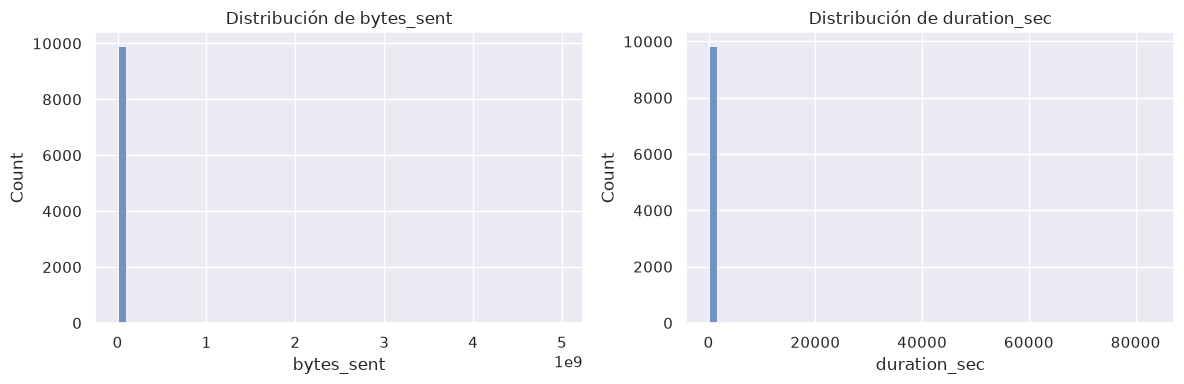

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['bytes_sent'], bins=50, ax=axes[0])
axes[0].set_title('Distribución de bytes_sent')
sns.histplot(df['duration_sec'], bins=50, ax=axes[1])
axes[1].set_title('Distribución de duration_sec')
plt.tight_layout()
plt.show()

In [4]:
# Nulos
print(df.isnull().sum())
df = df.dropna(subset=['bytes_sent', 'bytes_recv', 'duration_sec', 'packets'])

# Atípicos extremos: recorte por percentil 99.5 en variables de volumen
for col in ['bytes_sent', 'bytes_recv', 'duration_sec', 'packets']:
    limite = df[col].quantile(0.995)
    df = df[df[col] <= limite]

print('Registros tras limpieza:', len(df))

timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64
Registros tras limpieza: 9800


In [5]:
# Feature engineering
df['ratio_bytes'] = df['bytes_sent'] / df['bytes_recv'].replace(0, 1)
df['bytes_por_segundo'] = (df['bytes_sent'] + df['bytes_recv']) / df['duration_sec'].replace(0, 1)

df[['ratio_bytes', 'bytes_por_segundo']].describe()

,ratio_bytes,bytes_por_segundo
count,9.800000e+03,9.800000e+03
mean,2.320609e+03,1.029471e+05
std,1.101733e+05,1.000053e+06
min,2.766446e-05,3.350291e-02
25%,6.337226e-02,1.984995e+03
50%,4.197571e-01,7.539077e+03
75%,2.874736e+00,3.157575e+04
max,9.151127e+06,7.612021e+07


In [6]:
features = ['bytes_sent', 'bytes_recv', 'dst_port', 'duration_sec', 'packets', 'ratio_bytes', 'bytes_por_segundo']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features, index=df.index)
X_scaled.head()

,bytes_sent,bytes_recv,dst_port,duration_sec,packets,ratio_bytes,bytes_por_segundo
0,-0.231199,-0.314782,-0.719588,-0.055983,-0.137039,-0.021061,-0.101510
1,3.739809,-0.287774,-0.719588,-0.048288,0.288487,-0.020572,-0.034996
2,-0.222888,0.746243,-0.662413,-0.076386,-0.136736,-0.021064,0.043674
3,0.256974,-0.301797,-0.719046,-0.078417,-0.040018,-0.020989,0.064864
4,-0.231151,-0.345449,-0.274517,-0.070514,-0.135978,-0.021057,-0.100911


## Tarea 3.2 — Entrenamiento del modelo

In [7]:
modelo = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
modelo.fit(X_scaled)

predicciones = modelo.predict(X_scaled)  # -1 = anomalia, 1 = normal
df['prediccion'] = predicciones
df['prediccion'].value_counts()

prediccion
 1    9311
-1     489
Name: count, dtype: int64

Precision: 0.456
Recall:    0.637
F1-Score:  0.532


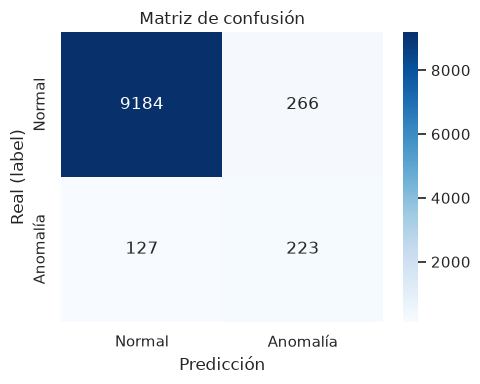

In [8]:
y_true = (df['label'] == 'anomaly').astype(int)
y_pred = (df['prediccion'] == -1).astype(int)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f'Precision: {precision:.3f}')
print(f'Recall:    {recall:.3f}')
print(f'F1-Score:  {f1:.3f}')

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalía'], yticklabels=['Normal', 'Anomalía'])
plt.xlabel('Predicción')
plt.ylabel('Real (label)')
plt.title('Matriz de confusión')
plt.tight_layout()
plt.show()

## Tarea 3.3 — Interpretación y umbral dinámico

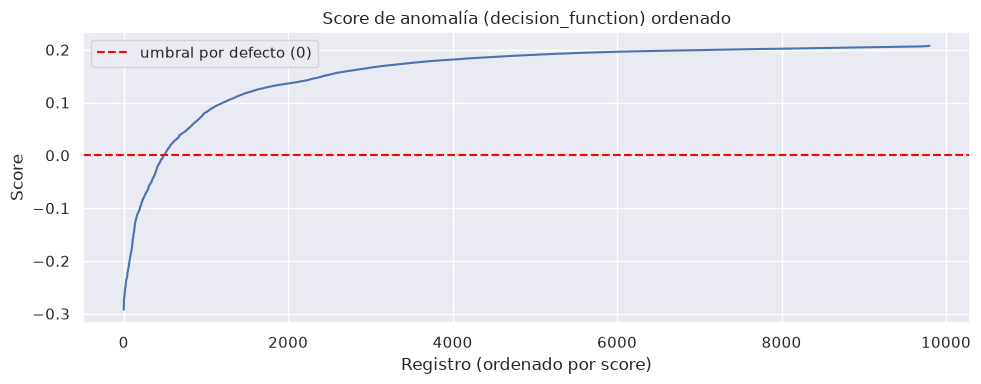

In [9]:
df['score'] = modelo.decision_function(X_scaled)

plt.figure(figsize=(10, 4))
plt.plot(df['score'].sort_values().values)
plt.axhline(0, color='red', linestyle='--', label='umbral por defecto (0)')
plt.title('Score de anomalía (decision_function) ordenado')
plt.xlabel('Registro (ordenado por score)')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

Umbral óptimo: 0.0168 -> F1: 0.551


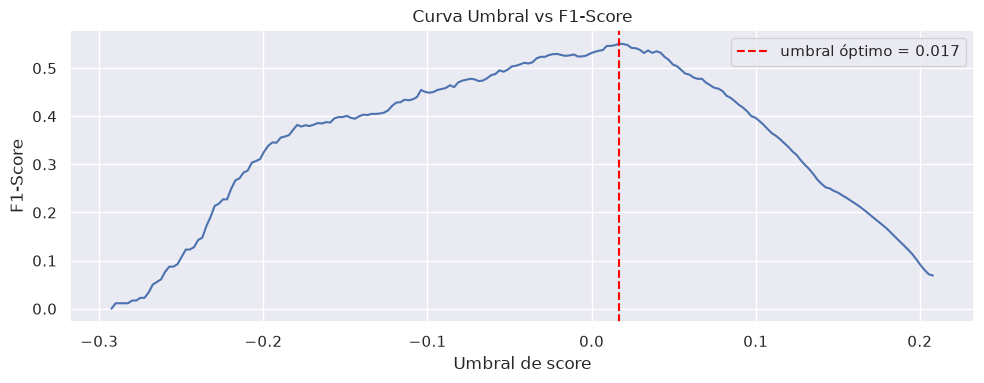

In [10]:
umbrales = np.linspace(df['score'].min(), df['score'].max(), 200)
f1_scores = []
for u in umbrales:
    pred_u = (df['score'] < u).astype(int)  # < umbral => anomalia
    f1_scores.append(f1_score(y_true, pred_u))

umbral_optimo = umbrales[int(np.argmax(f1_scores))]
f1_optimo = max(f1_scores)
print(f'Umbral óptimo: {umbral_optimo:.4f} -> F1: {f1_optimo:.3f}')

plt.figure(figsize=(10, 4))
plt.plot(umbrales, f1_scores)
plt.axvline(umbral_optimo, color='red', linestyle='--', label=f'umbral óptimo = {umbral_optimo:.3f}')
plt.title('Curva Umbral vs F1-Score')
plt.xlabel('Umbral de score')
plt.ylabel('F1-Score')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
top10_anomalas = df.sort_values('score').head(10)
top10_anomalas

,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label,ratio_bytes,bytes_por_segundo,prediccion,score
9667,2024-05-14 18:52:35,10.0.1.254,14.125.240.42,80,TCP,6978062,155,1.39,84490,anomaly,45019.754839,5.020300e+06,-1,-0.292560
3935,2024-05-02 05:32:06,10.0.1.206,76.196.246.10,80,ICMP,9992469,230,1.10,67206,anomaly,43445.517391,9.084272e+06,-1,-0.290352
1652,2024-05-22 04:24:05,10.0.1.83,134.254.60.66,53,ICMP,8746305,11,7.41,76098,anomaly,795118.636364,1.180340e+06,-1,-0.280028
2756,2024-05-21 00:36:46,10.0.0.136,91.240.118.172,443,TCP,7245199,54,11.98,95061,anomaly,134170.351852,6.047790e+05,-1,-0.275114
3373,2024-05-30 07:17:09,10.0.1.114,185.220.101.45,53,UDP,9687834,391,5.00,80654,anomaly,24777.069054,1.937645e+06,-1,-0.270590
7663,2024-05-16 16:37:46,10.0.1.97,23.129.64.214,53,UDP,9981411,324,6.15,78889,anomaly,30806.824074,1.623046e+06,-1,-0.270132
5058,2024-05-05 10:16:01,10.0.3.101,61.47.234.82,53,UDP,7440598,10,5.95,57096,anomaly,744059.800000,1.250522e+06,-1,-0.269297
300,2024-05-29 06:39:21,10.0.1.148,17.126.123.46,53,TCP,9109114,123,19.39,97587,anomaly,74057.837398,4.697905e+05,-1,-0.268650
6493,2024-05-29 23:40:17,10.0.3.25,94.184.124.134,80,UDP,5077456,306,1.04,79228,anomaly,16592.993464,4.882463e+06,-1,-0.268490
1599,2024-05-13 17:45:48,10.0.3.101,90.104.72.227,443,TCP,5523770,152,4.30,91119,anomaly,36340.592105,1.284633e+06,-1,-0.265844


**Interpretación (completar tras ejecutar con datos reales):**

Las 10 conexiones con el score más bajo (más anómalas) suelen compartir alguno de estos rasgos: volúmenes de `bytes_sent` muy por encima de la media (posible exfiltración de datos), `duration_sec` extremadamente corto combinado con `packets` alto (posible escaneo de puertos o flood), o `ratio_bytes` muy desbalanceado (mucho más tráfico saliente que entrante, típico de exfiltración o de un host comprometido actuando como C2 beacon). Puertos de destino poco comunes (`dst_port` fuera del rango de servicios estándar) en conexiones de alto volumen refuerzan la hipótesis de actividad maliciosa más que de tráfico legítimo mal etiquetado.

## Tarea 3.4 — Exportación del modelo

In [12]:
joblib.dump({'modelo': modelo, 'scaler': scaler, 'features': features, 'umbral': umbral_optimo}, 'modelo_anomalias.pkl')
print('Modelo guardado en lab3/modelo_anomalias.pkl')

Modelo guardado en lab3/modelo_anomalias.pkl
